### Customer Segmentation
- RFM Feature Engineering and K-Means Clustering

## Objectives

1. Load the processed customer dataset produced by `data_manipulation.ipynb` (validated in `eda.ipynb`).
2. Engineer RFM features at the customer level: Recency, Frequency, Monetary (revenue), and total Margin.
3. Scale the features so distance-based clustering is not dominated by any single feature's units.
4. Choose the number of clusters using the elbow method and silhouette score.
5. Fit K-Means and profile each resulting segment in business terms.

This is unsupervised learning: there is no labelled "correct" segment to predict, so there is no train/test split. Customers are grouped by similarity in behaviour, and the resulting clusters are interpreted after the fact.

In [1]:
%matplotlib inline

# Core Python utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Pandas display settings: readable but not noisy
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [2]:
%%capture

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", PROCESSED_DATA_DIR)
print("Reports folder:", REPORTS_DIR)

### Load Processed Data

In [3]:
customer_data = pd.read_csv(PROCESSED_DATA_DIR / "customer_data.csv", parse_dates=["order_date"])

print(f"Rows: {customer_data.shape[0]:,}")
print(f"Columns: {customer_data.shape[1]:,}")

customer_data.head()

Rows: 3,305
Columns: 15


,order_id,customer_id,order_date,discount_rate,signup_date,country,channel,order_item_id,product_id,quantity,revenue,margin,category,unit_cost,price
0,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000001,PROD005,5,"1,465.44",622.79,Mobile,168.53,366.36
1,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000002,PROD010,1,173.88,136.75,Mobile,37.13,217.35
2,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000003,PROD010,1,173.88,136.75,Mobile,37.13,217.35
3,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000004,PROD004,2,55.22,-30.94,Accessories,43.08,34.51
4,ORD000002,CUST0001,2024-09-27,0.00,2024-11-23,UK,Organic,ITEM0000005,PROD004,2,69.02,-17.14,Accessories,43.08,34.51


## 1. RFM Feature Engineering

- **Recency**: days between the customer's most recent order and the day after the last order date in the dataset.
- **Frequency**: number of distinct orders placed by the customer.
- **Monetary**: total revenue generated by the customer.
- **Margin**: total profit (margin) generated by the customer included alongside the standard RFM trio because this project's stated focus is profit, not just revenue.

In [4]:
snapshot_date = customer_data["order_date"].max() + pd.Timedelta(days=1)

rfm = customer_data.groupby("customer_id").agg(
    recency=("order_date", lambda dates: (snapshot_date - dates.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum"),
    margin=("margin", "sum"),
).reset_index()

print(f"Customers: {rfm.shape[0]:,}")
rfm.head()

Customers: 250


,customer_id,recency,frequency,monetary,margin
0,CUST0001,11,8,"24,889.49","15,626.78"
1,CUST0002,637,1,"1,817.79","1,171.71"
2,CUST0003,220,10,"31,189.17","20,950.93"
3,CUST0004,129,3,"9,056.97","5,565.20"
4,CUST0005,8,7,"19,044.42","11,248.30"


### RFM Feature Distributions

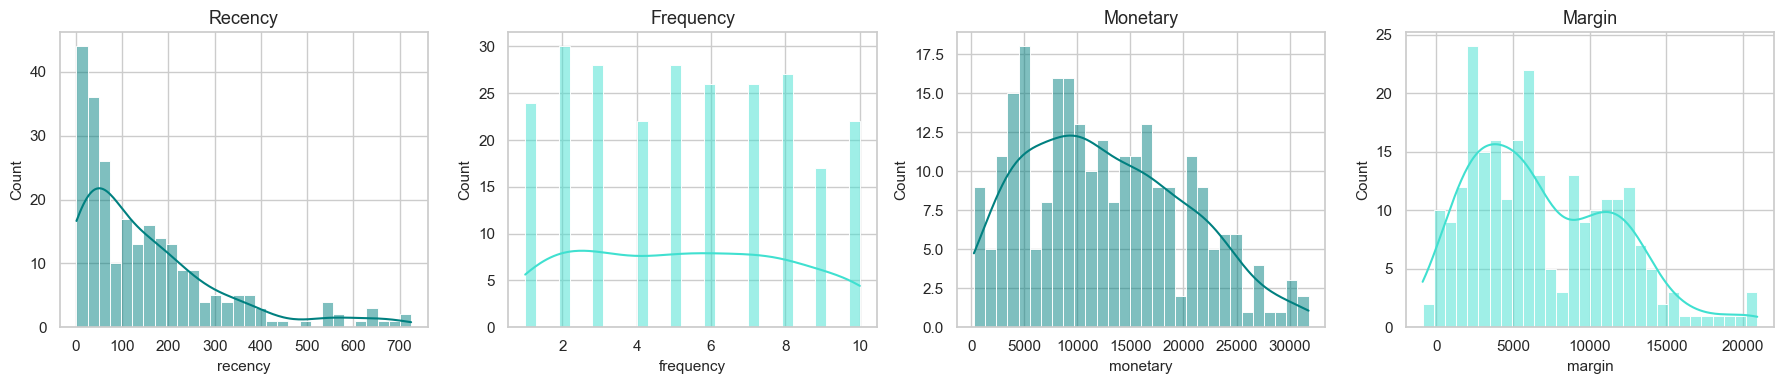

,recency,frequency,monetary,margin
count,250.00,250.00,250.00,250.00
mean,155.08,5.29,"12,610.60","6,928.21"
std,157.28,2.81,"7,510.50","4,717.36"
min,1.00,1.00,245.74,-894.64
25%,35.25,3.00,"6,348.78","3,129.95"
50%,108.00,5.00,"11,771.31","5,902.83"
75%,211.00,8.00,"17,796.78","10,592.05"
max,725.00,10.00,"31,790.74","20,950.93"


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col, color in zip(
    axes,
    ["recency", "frequency", "monetary", "margin"],
    ["#008080", "#40E0D0", "#008080", "#40E0D0"],
):
    sns.histplot(rfm[col], bins=30, kde=True, ax=ax, color=color)
    ax.set_title(col.title())

plt.tight_layout()
plt.show()

rfm[["recency", "frequency", "monetary", "margin"]].describe()

## 2. Scale Features

K-Means is distance-based, so features on different scales (days vs. order counts vs. currency-like units) would let the largest-magnitude feature dominate the distance calculation. Standardising to zero mean and unit variance puts all four features on equal footing.

In [6]:
feature_cols = ["recency", "frequency", "monetary", "margin"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[feature_cols])

print("Scaled feature means (should be ~0):", rfm_scaled.mean(axis=0).round(3))
print("Scaled feature stds (should be ~1):", rfm_scaled.std(axis=0).round(3))

Scaled feature means (should be ~0): [-0.  0. -0.  0.]
Scaled feature stds (should be ~1): [1. 1. 1. 1.]


## 3. Choose the Number of Clusters

Two diagnostics, checked together:

- **Elbow method**: plots within-cluster sum of squares (inertia) against `k`. Look for the point where adding another cluster stops reducing inertia much.
- **Silhouette score**: measures how well-separated the clusters are (higher is better, range -1 to 1). Used to sanity-check the elbow's choice of `k`.

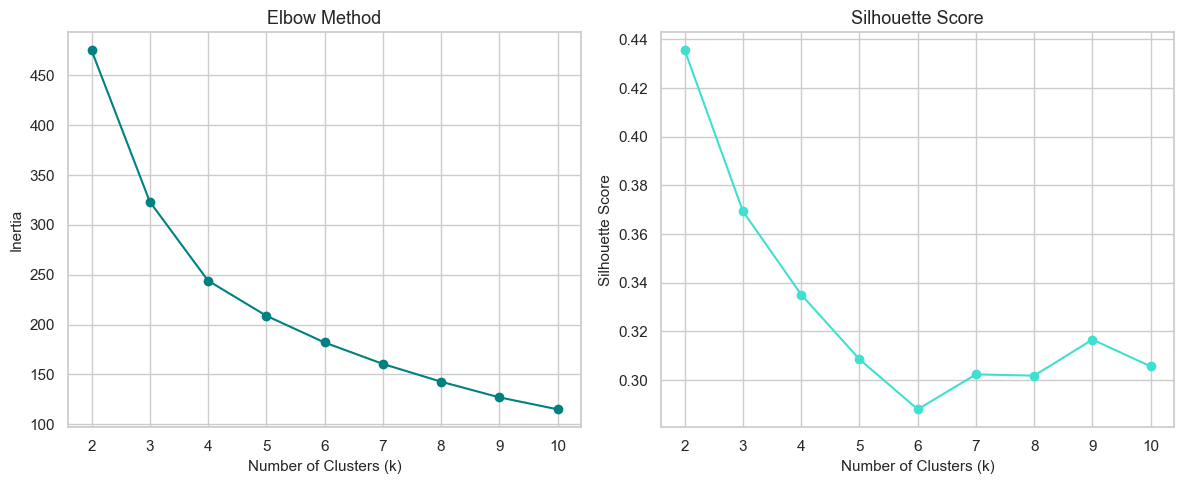

,k,inertia,silhouette_score
0,2,475.15,0.44
1,3,323.23,0.37
2,4,244.07,0.34
3,5,208.86,0.31
4,6,182.06,0.29
5,7,160.55,0.30
6,8,142.72,0.30
7,9,127.02,0.32
8,10,115.01,0.31


In [7]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_range), inertias, marker="o", color="#008080")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="#40E0D0")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_range), "inertia": inertias, "silhouette_score": silhouette_scores})

## 4. Fit K-Means

Set `N_CLUSTERS` based on the elbow/silhouette plots above, then fit the final model.

In [8]:
N_CLUSTERS = 4 # from the elbow and silhouette plots, 4 clusters seems reasonable
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

print(f"Fitted K-Means with k={N_CLUSTERS}")
print("Silhouette score:", round(silhouette_score(rfm_scaled, rfm["cluster"]), 3))

rfm["cluster"].value_counts().sort_index()

Fitted K-Means with k=4
Silhouette score: 0.335


cluster
0    28
1    62
2    85
3    75
Name: count, dtype: int64

## 5. Profile the Segments

,recency,frequency,monetary,margin,customer_count
cluster,,,,,
0,501.54,1.61,"3,630.63","1,758.53",28
1,96.24,8.52,"22,843.04","13,243.61",62
2,149.39,3.12,"6,823.19","3,562.58",85
3,80.83,6.47,"14,063.38","7,451.87",75


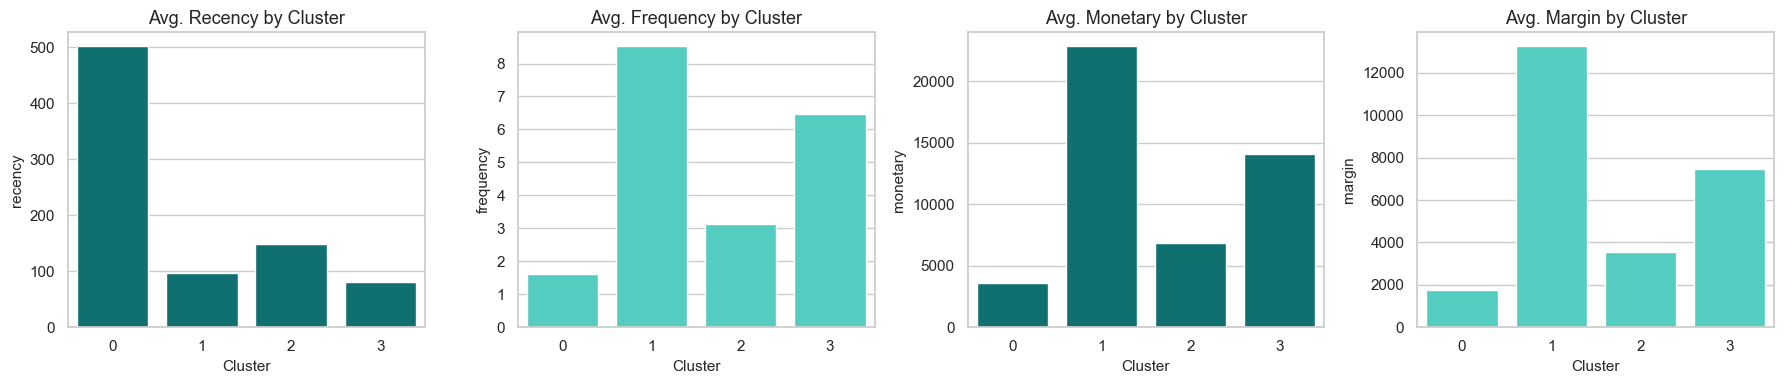

In [9]:
cluster_profile = rfm.groupby("cluster")[feature_cols].mean().round(2)
cluster_profile["customer_count"] = rfm["cluster"].value_counts().sort_index()
display(cluster_profile)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, color in zip(axes, feature_cols, ["#008080", "#40E0D0", "#008080", "#40E0D0"]):
    sns.barplot(x=cluster_profile.index, y=cluster_profile[col], ax=ax, color=color)
    ax.set_title(f"Avg. {col.title()} by Cluster")
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

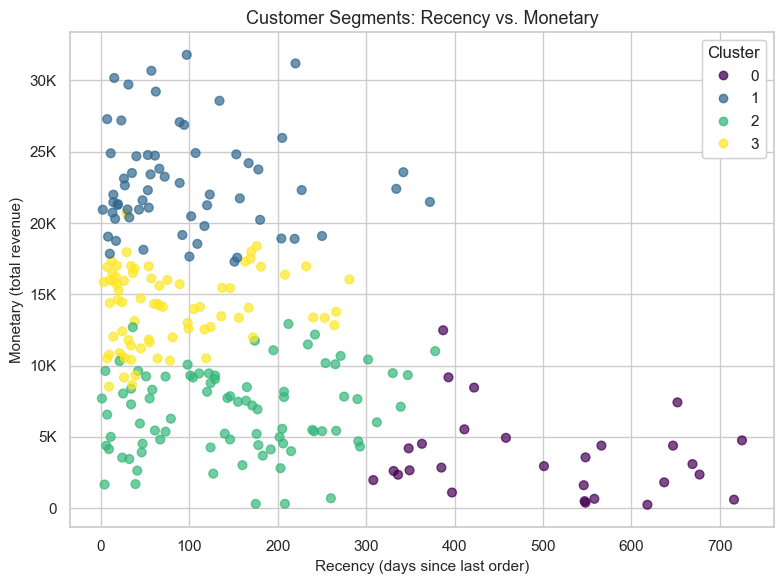

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    rfm["recency"], rfm["monetary"],
    c=rfm["cluster"], cmap="viridis", alpha=0.7, s=40,
)
ax.set_title("Customer Segments: Recency vs. Monetary")
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Monetary (total revenue)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:,.0f}K" if x != 0 else "0"))
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.tight_layout()
plt.show()

### Label the Segments

Review `cluster_profile` above and assign a business-meaningful name to each cluster number — for example, low recency + high frequency + high monetary/margin might be "Loyal High-Value", while high recency + low frequency might be "At Risk" or "Churned". Fill in `cluster_labels` to match what the profile table actually shows for this run.

In [11]:
cluster_labels = {
    0: "Churned / Lost",
    1: "Loyal High-Value",
    2: "At Risk / Low Engagement",
    3: "Active / Growing",
}

if cluster_labels:
    rfm["segment"] = rfm["cluster"].map(cluster_labels)
else:
    rfm["segment"] = "Cluster " + rfm["cluster"].astype(str)

rfm.head()

,customer_id,recency,frequency,monetary,margin,cluster,segment
0,CUST0001,11,8,"24,889.49","15,626.78",1,Loyal High-Value
1,CUST0002,637,1,"1,817.79","1,171.71",0,Churned / Lost
2,CUST0003,220,10,"31,189.17","20,950.93",1,Loyal High-Value
3,CUST0004,129,3,"9,056.97","5,565.20",2,At Risk / Low Engagement
4,CUST0005,8,7,"19,044.42","11,248.30",1,Loyal High-Value


In [12]:
rfm.to_csv(PROCESSED_DATA_DIR / "customer_segments.csv", index=False)
print("Saved customer segments to:", PROCESSED_DATA_DIR / "customer_segments.csv")

Saved customer segments to: /Users/ememakpan/Documents/New project/customer_segmentation_fullstack/data/processed/customer_segments.csv


## Conclusion

I engineered RFM features (recency, frequency, monetary) plus margin at the customer level, then standardized them before clustering, since K-Means is distance-based and the raw features weren't on comparable scales - recency runs in the hundreds of days, monetary and margin run into the tens of thousands, while frequency only spans 1-10. I checked the elbow method and silhouette score across k=2 to 10 and picked k=4 as the best balance between cluster cohesion (silhouette score 0.335) and business-usable granularity.

I fit K-Means and profiled the four resulting segments: Loyal High-Value (62 customers) - the most frequent, highest spend and margin group. Active/Growing (75) - recent and solid value, the nurture opportunity. At Risk/Low Engagement (85) - the largest group, but low frequency and value. Churned/Lost (28) - no order in roughly a year and a half, minimal historic spend.

This gives the business four clear, data-backed customer groups to act on: retention for the loyal segment, re-engagement for the at-risk group (the biggest opportunity by size), nurturing for the growing segment, and a win-back or deprioritization decision for the churned group. Before moving to the next level, the segments and RFM features are saved to `data/processed/customer_segments.csv`, ready to feed into a dashboard, report, or a backend service that keeps the segments updated as new transactions come in.